
# XGBoost Baseline — Incident Classification with Early Stopping

This notebook trains and evaluates **XGBoost** for the fixed three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

It uses:

1. `canonical_dataset_revised.csv`
2. `grouped_random_split_manifest_revised.csv`
3. `spatial_split_manifest_revised.csv`

The validation set is used for:

- early stopping;
- hyperparameter selection using **validation Macro-F1**.

The test set is evaluated only after the final configuration has been selected.

Early stopping monitors multiclass log-loss because it is smooth and natively supported by XGBoost.  
The selected model is still ranked using validation Macro-F1, which remains the study's primary metric.


In [2]:

# Run only if XGBoost is not installed:
# !pip install -U xgboost

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("XGBoost version:", xgb.__version__)

RANDOM_STATE = 42
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_INT = {label: i for i, label in enumerate(CLASS_ORDER)}
INT_TO_CLASS = {i: label for label, i in CLASS_TO_INT.items()}

# Change only DATA_DIR if the files are stored elsewhere.
DATA_DIR = Path(".")

CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")

OUTPUT_DIR = DATA_DIR / "xgboost_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files "
            "or update DATA_DIR."
        )

print("Output directory:", OUTPUT_DIR.resolve())


XGBoost version: 3.1.1
Output directory: /Users/andishahifahmuthahharah/Downloads/xgboost_outputs


## 1. Load and validate the fixed data

In [3]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

assert canonical["event_sample_id"].is_unique
assert grouped_manifest["event_sample_id"].is_unique
assert spatial_manifest["event_sample_id"].is_unique

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"])
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"])
assert set(canonical["target_class"].unique()) == set(CLASS_ORDER)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)

print("Integrity checks passed.")


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179


Integrity checks passed.


## 2. Leakage-safe traffic feature engineering

In [4]:

FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    flow = df[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    X = pd.DataFrame(index=df.index)

    for j, col in enumerate(FLOW_COLS):
        X[f"log1p_{col}"] = np.log1p(flow[:, j])

    diffs = np.diff(flow, axis=1)
    denom = np.maximum(np.abs(flow[:, :-1]), 1.0)
    rel = np.clip(diffs / denom, -10.0, 10.0)

    step_names = [
        "m3_to_m2",
        "m2_to_m1",
        "m1_to_t0",
        "t0_to_p1",
        "p1_to_p2",
        "p2_to_p3",
    ]

    for j, name in enumerate(step_names):
        X[f"diff_{name}"] = diffs[:, j]
        X[f"rel_change_{name}"] = rel[:, j]

    pre = flow[:, :3]
    response = flow[:, 3:]

    X["pre_mean"] = pre.mean(axis=1)
    X["response_mean"] = response.mean(axis=1)
    X["mean_shift"] = X["response_mean"] - X["pre_mean"]
    X["response_pre_ratio"] = X["response_mean"] / np.maximum(X["pre_mean"], 1.0)

    X["onset_jump"] = flow[:, 3] - flow[:, 2]
    X["pre_slope"] = (flow[:, 2] - flow[:, 0]) / 2.0
    X["response_slope"] = (flow[:, 6] - flow[:, 3]) / 3.0

    X["window_mean"] = flow.mean(axis=1)
    X["window_std"] = flow.std(axis=1)
    X["window_min"] = flow.min(axis=1)
    X["window_max"] = flow.max(axis=1)
    X["window_range"] = X["window_max"] - X["window_min"]

    X["max_drop"] = np.minimum(diffs, 0).min(axis=1)
    X["max_rise"] = np.maximum(diffs, 0).max(axis=1)
    X["max_abs_change"] = np.abs(diffs).max(axis=1)
    X["cumulative_post_change"] = flow[:, 6] - flow[:, 3]

    if not np.isfinite(X.to_numpy()).all():
        raise ValueError("Engineered features contain NaN or infinite values.")

    return X.astype(np.float32)



## 3. Compact XGBoost search grid

The model uses a large maximum number of boosting rounds, but early stopping normally stops training much earlier.

Regularisation is controlled by:

- shallow tree depth;
- learning rate;
- row and feature subsampling;
- L1/L2 penalties;
- minimum child weight.

A compact grid is used to keep runtime manageable.


In [5]:

PARAM_GRID = [
    {
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "min_child_weight": min_child_weight,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
    }
    for max_depth in [3, 5]
    for learning_rate in [0.03, 0.07]
    for min_child_weight in [5, 15]
    for subsample in [0.8]
    for colsample_bytree in [0.8]
    for reg_alpha in [0.0, 0.5]
    for reg_lambda in [2.0]
]

N_ESTIMATORS = 2000
EARLY_STOPPING_ROUNDS = 50

print("Parameter combinations:", len(PARAM_GRID))


Parameter combinations: 16


In [6]:

def merge_split(canonical_df: pd.DataFrame, manifest: pd.DataFrame) -> pd.DataFrame:
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df)
    assert (
        merged["target_class"] == merged["target_class_manifest"]
    ).all()

    return merged.drop(columns="target_class_manifest")

def encode_target(y: pd.Series) -> np.ndarray:
    encoded = y.map(CLASS_TO_INT)
    if encoded.isna().any():
        raise ValueError("Unknown target label found.")
    return encoded.astype(int).to_numpy()

def decode_target(y_int) -> np.ndarray:
    return np.array([INT_TO_CLASS[int(v)] for v in y_int])

def metric_row(y_true_label, y_pred_label):
    return {
        "accuracy": accuracy_score(y_true_label, y_pred_label),
        "balanced_accuracy": balanced_accuracy_score(y_true_label, y_pred_label),
        "macro_f1": f1_score(
            y_true_label, y_pred_label, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true_label, y_pred_label, average="weighted", zero_division=0
        ),
    }

def make_xgb_model(params: dict):
    # early_stopping_rounds is placed in the estimator constructor,
    # which is the supported interface in modern XGBoost releases.
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_ORDER),
        n_estimators=N_ESTIMATORS,
        tree_method="hist",
        eval_metric="mlogloss",
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **params,
    )


## 4. Training, early stopping, and evaluation

In [7]:

def run_xgboost_experiment(split_name: str, manifest: pd.DataFrame):
    data = merge_split(canonical, manifest)
    X = build_features(data)
    y_label = data["target_class"].astype(str)
    y_int = encode_target(y_label)

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train = X.loc[masks["train"]]
    X_val = X.loc[masks["validation"]]
    X_test = X.loc[masks["test"]]

    y_train_label = y_label.loc[masks["train"]]
    y_val_label = y_label.loc[masks["validation"]]
    y_test_label = y_label.loc[masks["test"]]

    y_train = y_int[masks["train"]]
    y_val = y_int[masks["validation"]]
    y_test = y_int[masks["test"]]

    # Balanced sample weights are computed from training data only.
    train_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train_label,
    )

    print(f"\n=== {split_name} ===")
    print("Train / validation / test:", len(y_train), len(y_val), len(y_test))

    split_counts = (
        data.groupby(["split", "target_class"])
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=["train", "validation", "test"],
            columns=CLASS_ORDER,
            fill_value=0,
        )
    )
    display(split_counts)

    search_rows = []
    models = []

    for i, params in enumerate(PARAM_GRID, start=1):
        model = make_xgb_model(params)

        model.fit(
            X_train,
            y_train,
            sample_weight=train_weights,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        val_pred_int = model.predict(X_val)
        val_pred_label = decode_target(val_pred_int)

        row = {
            **params,
            "best_iteration": int(model.best_iteration),
            "best_validation_mlogloss": float(model.best_score),
            **metric_row(y_val_label, val_pred_label),
        }

        search_rows.append(row)
        models.append(model)

        print(
            f"{i:02d}/{len(PARAM_GRID)} | "
            f"best_iteration={model.best_iteration:4d} | "
            f"val_macro_f1={row['macro_f1']:.4f} | "
            f"val_mlogloss={row['best_validation_mlogloss']:.4f}"
        )

    search_df = pd.DataFrame(search_rows)

    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "best_validation_mlogloss"],
        ascending=[False, False, True],
    )

    best_idx = ranking.index[0]
    best_model = models[best_idx]
    best_params = PARAM_GRID[best_idx]

    print("\nBest validation parameters:")
    print(best_params)
    print("Best iteration:", best_model.best_iteration)
    print("Best validation mlogloss:", best_model.best_score)

    display(ranking.head(10))

    partition_results = []
    prediction_frames = []

    for part, X_part, y_part_label in [
        ("train", X_train, y_train_label),
        ("validation", X_val, y_val_label),
        ("test", X_test, y_test_label),
    ]:
        pred_int = best_model.predict(X_part)
        pred_label = decode_target(pred_int)

        partition_results.append({
            "split_scheme": split_name,
            "partition": part,
            "best_iteration": int(best_model.best_iteration),
            **metric_row(y_part_label, pred_label),
        })

        ids = data.loc[masks[part], "event_sample_id"].to_numpy()

        prediction_frames.append(pd.DataFrame({
            "event_sample_id": ids,
            "split_scheme": split_name,
            "partition": part,
            "y_true": y_part_label.to_numpy(),
            "y_pred": pred_label,
        }))

    results_df = pd.DataFrame(partition_results)
    prediction_df = pd.concat(prediction_frames, ignore_index=True)

    test_pred = prediction_df.loc[
        prediction_df["partition"].eq("test"), "y_pred"
    ].to_numpy()

    print("\nOverall metrics:")
    display(results_df)

    print("\nTest classification report:")
    report_df = pd.DataFrame(
        classification_report(
            y_test_label,
            test_pred,
            labels=CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T
    display(report_df)

    safe_name = split_name.lower().replace("-", "_").replace(" ", "_")

    search_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_hyperparameter_search.csv",
        index=False,
    )
    results_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_metrics.csv",
        index=False,
    )
    prediction_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_predictions.csv",
        index=False,
    )
    report_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_test_classification_report.csv"
    )

    best_metadata = {
        **best_params,
        "n_estimators_maximum": N_ESTIMATORS,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "best_iteration": int(best_model.best_iteration),
        "best_validation_mlogloss": float(best_model.best_score),
    }

    with open(OUTPUT_DIR / f"{safe_name}_best_params.json", "w") as f:
        json.dump(best_metadata, f, indent=2)

    best_model.save_model(
        OUTPUT_DIR / f"{safe_name}_xgboost_model.json"
    )
    joblib.dump(
        best_model,
        OUTPUT_DIR / f"{safe_name}_xgboost_model.joblib",
    )

    # Training history
    evals_result = best_model.evals_result()
    history = pd.DataFrame({
        "iteration": np.arange(
            len(evals_result["validation_0"]["mlogloss"])
        ),
        "validation_mlogloss": evals_result["validation_0"]["mlogloss"],
    })
    history.to_csv(
        OUTPUT_DIR / f"{safe_name}_training_history.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["iteration"], history["validation_mlogloss"])
    ax.axvline(
        best_model.best_iteration,
        linestyle="--",
        label=f"Best iteration = {best_model.best_iteration}",
    )
    ax.set_title(f"XGBoost — {split_name} early stopping")
    ax.set_xlabel("Boosting iteration")
    ax.set_ylabel("Validation multiclass log-loss")
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_early_stopping_curve.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_label,
        test_pred,
        labels=CLASS_ORDER,
        display_labels=CLASS_ORDER,
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"XGBoost — {split_name} test confusion matrix")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_confusion_matrix.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    # Feature importance
    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    importance_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_feature_importance.csv",
        index=False,
    )

    display(importance_df.head(20))

    top = importance_df.head(15).sort_values("importance")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["feature"], top["importance"])
    ax.set_title(f"XGBoost — {split_name} feature importance")
    ax.set_xlabel("Importance")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_feature_importance.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    return {
        "model": best_model,
        "best_params": best_metadata,
        "metrics": results_df,
        "report": report_df,
        "predictions": prediction_df,
        "importance": importance_df,
        "search": search_df,
        "history": history,
    }


## 5. Grouped-random experiment


=== Grouped-random ===
Train / validation / test: 3685 784 796


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2510,352,823
validation,530,79,175
test,541,74,181


01/16 | best_iteration= 672 | val_macro_f1=0.2900 | val_mlogloss=1.0575
02/16 | best_iteration= 672 | val_macro_f1=0.2865 | val_mlogloss=1.0585
03/16 | best_iteration= 672 | val_macro_f1=0.2870 | val_mlogloss=1.0626
04/16 | best_iteration=1090 | val_macro_f1=0.3001 | val_mlogloss=1.0514
05/16 | best_iteration= 644 | val_macro_f1=0.2946 | val_mlogloss=1.0417
06/16 | best_iteration= 298 | val_macro_f1=0.2894 | val_mlogloss=1.0538
07/16 | best_iteration= 298 | val_macro_f1=0.2890 | val_mlogloss=1.0571
08/16 | best_iteration= 298 | val_macro_f1=0.2947 | val_mlogloss=1.0560
09/16 | best_iteration= 665 | val_macro_f1=0.2997 | val_mlogloss=1.0246
10/16 | best_iteration= 615 | val_macro_f1=0.3045 | val_mlogloss=1.0220
11/16 | best_iteration= 656 | val_macro_f1=0.3005 | val_mlogloss=1.0288
12/16 | best_iteration= 698 | val_macro_f1=0.3026 | val_mlogloss=1.0284
13/16 | best_iteration= 259 | val_macro_f1=0.2946 | val_mlogloss=1.0229
14/16 | best_iteration= 300 | val_macro_f1=0.2973 | val_mlogloss

,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,best_iteration,best_validation_mlogloss,accuracy,balanced_accuracy,macro_f1,weighted_f1
9,5,0.03,5,0.8,0.8,0.5,2.0,615,1.021996,0.450255,0.308860,0.304452,0.467459
11,5,0.03,15,0.8,0.8,0.5,2.0,698,1.028375,0.428571,0.310689,0.302633,0.453127
14,5,0.07,15,0.8,0.8,0.0,2.0,300,1.031828,0.429847,0.307491,0.301190,0.455343
15,5,0.07,15,0.8,0.8,0.5,2.0,267,1.033658,0.424745,0.306014,0.300714,0.451474
10,5,0.03,15,0.8,0.8,0.0,2.0,656,1.028766,0.427296,0.307509,0.300475,0.451815
3,3,0.03,15,0.8,0.8,0.5,2.0,1090,1.051380,0.410714,0.311854,0.300104,0.440141
8,5,0.03,5,0.8,0.8,0.0,2.0,665,1.024622,0.457908,0.306728,0.299689,0.471916
13,5,0.07,5,0.8,0.8,0.5,2.0,300,1.025653,0.445153,0.302754,0.297316,0.462406
7,3,0.07,15,0.8,0.8,0.5,2.0,298,1.055994,0.391582,0.309838,0.294674,0.424194
12,5,0.07,5,0.8,0.8,0.0,2.0,259,1.022919,0.446429,0.301068,0.294616,0.464662



Overall metrics:


,split_scheme,partition,best_iteration,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,train,615,0.800000,0.837259,0.794283,0.814189
1,Grouped-random,validation,615,0.450255,0.308860,0.304452,0.467459
2,Grouped-random,test,615,0.494975,0.352464,0.336239,0.507017



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.695749,0.574861,0.629555,541.000000
ACCIDENT,0.075000,0.040541,0.052632,74.000000
OTHER_DISRUPTION,0.258900,0.441989,0.326531,181.000000
accuracy,0.494975,0.494975,0.494975,0.494975
macro avg,0.343216,0.352464,0.336239,796.000000
weighted avg,0.538708,0.494975,0.507017,796.000000


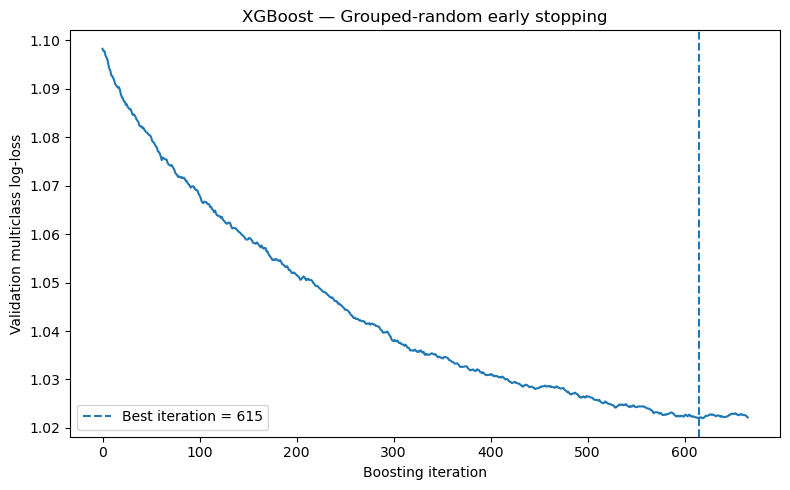

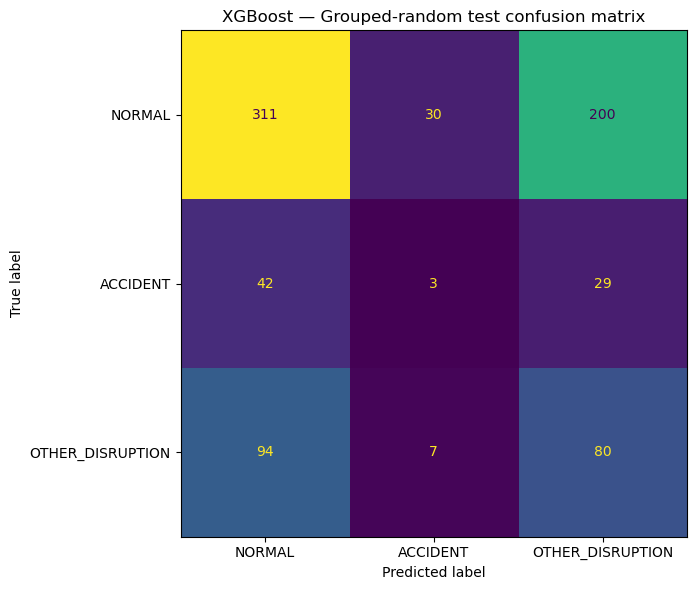

,feature,importance
26,window_mean,0.032029
25,response_slope,0.031813
33,max_abs_change,0.031218
20,response_mean,0.030861
3,log1p_flow_t0,0.030314
22,response_pre_ratio,0.030159
32,max_rise,0.029705
19,pre_mean,0.029673
15,diff_p1_to_p2,0.029086
0,log1p_flow_t_minus_3,0.029085


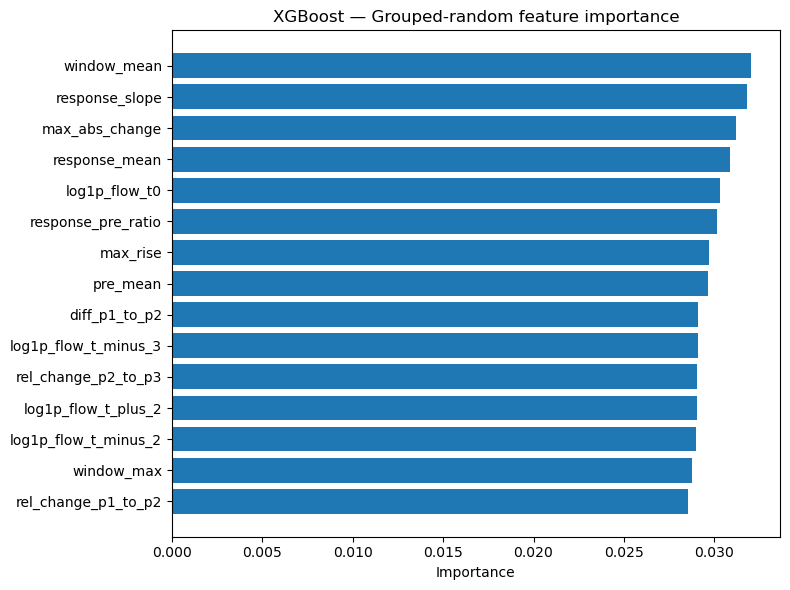

In [8]:

grouped_results = run_xgboost_experiment(
    split_name="Grouped-random",
    manifest=grouped_manifest,
)


## 6. Spatial holdout experiment


=== Spatial holdout ===
Train / validation / test: 3703 806 756


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2517,347,839
validation,549,84,173
test,515,74,167


01/16 | best_iteration= 671 | val_macro_f1=0.3125 | val_mlogloss=1.0529
02/16 | best_iteration= 670 | val_macro_f1=0.3167 | val_mlogloss=1.0509
03/16 | best_iteration= 931 | val_macro_f1=0.3059 | val_mlogloss=1.0546
04/16 | best_iteration= 671 | val_macro_f1=0.3083 | val_mlogloss=1.0610
05/16 | best_iteration= 506 | val_macro_f1=0.3241 | val_mlogloss=1.0399
06/16 | best_iteration= 346 | val_macro_f1=0.3224 | val_mlogloss=1.0487
07/16 | best_iteration= 295 | val_macro_f1=0.3117 | val_mlogloss=1.0625
08/16 | best_iteration= 317 | val_macro_f1=0.2977 | val_mlogloss=1.0611
09/16 | best_iteration= 793 | val_macro_f1=0.3270 | val_mlogloss=0.9930
10/16 | best_iteration= 845 | val_macro_f1=0.3229 | val_mlogloss=0.9954
11/16 | best_iteration= 897 | val_macro_f1=0.3198 | val_mlogloss=1.0202
12/16 | best_iteration= 845 | val_macro_f1=0.3240 | val_mlogloss=1.0193
13/16 | best_iteration= 345 | val_macro_f1=0.3205 | val_mlogloss=1.0014
14/16 | best_iteration= 326 | val_macro_f1=0.3263 | val_mlogloss

,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,best_iteration,best_validation_mlogloss,accuracy,balanced_accuracy,macro_f1,weighted_f1
8,5,0.03,5,0.8,0.8,0.0,2.0,793,0.992995,0.475186,0.344960,0.326971,0.492095
14,5,0.07,15,0.8,0.8,0.0,2.0,308,1.025146,0.429280,0.353816,0.326964,0.458809
13,5,0.07,5,0.8,0.8,0.5,2.0,326,0.994918,0.466501,0.348627,0.326320,0.484108
4,3,0.07,5,0.8,0.8,0.0,2.0,506,1.039938,0.419355,0.352320,0.324068,0.450080
11,5,0.03,15,0.8,0.8,0.5,2.0,845,1.019325,0.440447,0.341403,0.324029,0.466579
9,5,0.03,5,0.8,0.8,0.5,2.0,845,0.995440,0.470223,0.339892,0.322896,0.487815
5,3,0.07,5,0.8,0.8,0.5,2.0,346,1.048709,0.395782,0.357589,0.322405,0.430629
12,5,0.07,5,0.8,0.8,0.0,2.0,345,1.001396,0.471464,0.339777,0.320491,0.488245
10,5,0.03,15,0.8,0.8,0.0,2.0,897,1.020219,0.440447,0.341279,0.319750,0.465715
1,3,0.03,5,0.8,0.8,0.5,2.0,670,1.050887,0.395782,0.348228,0.316665,0.430715



Overall metrics:


,split_scheme,partition,best_iteration,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Spatial holdout,train,793,0.829328,0.863332,0.822720,0.840439
1,Spatial holdout,validation,793,0.475186,0.344960,0.326971,0.492095
2,Spatial holdout,test,793,0.411376,0.329238,0.286707,0.425028



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.660606,0.423301,0.515976,515.000000
ACCIDENT,0.040000,0.013514,0.020202,74.000000
OTHER_DISRUPTION,0.229426,0.550898,0.323944,167.000000
accuracy,0.411376,0.411376,0.411376,0.411376
macro avg,0.310011,0.329238,0.286707,756.000000
weighted avg,0.504612,0.411376,0.425028,756.000000


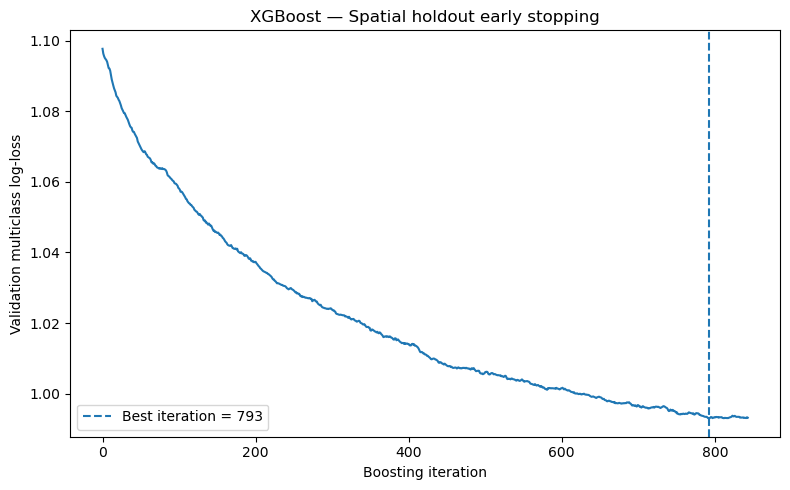

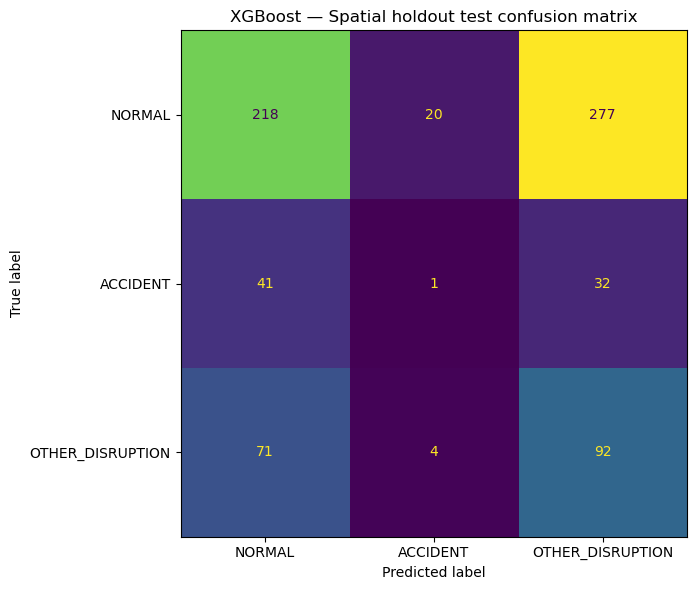

,feature,importance
34,cumulative_post_change,0.033645
20,response_mean,0.031795
19,pre_mean,0.031737
26,window_mean,0.031049
32,max_rise,0.030663
25,response_slope,0.030502
33,max_abs_change,0.030093
8,rel_change_m3_to_m2,0.030000
4,log1p_flow_t_plus_1,0.029785
31,max_drop,0.029516


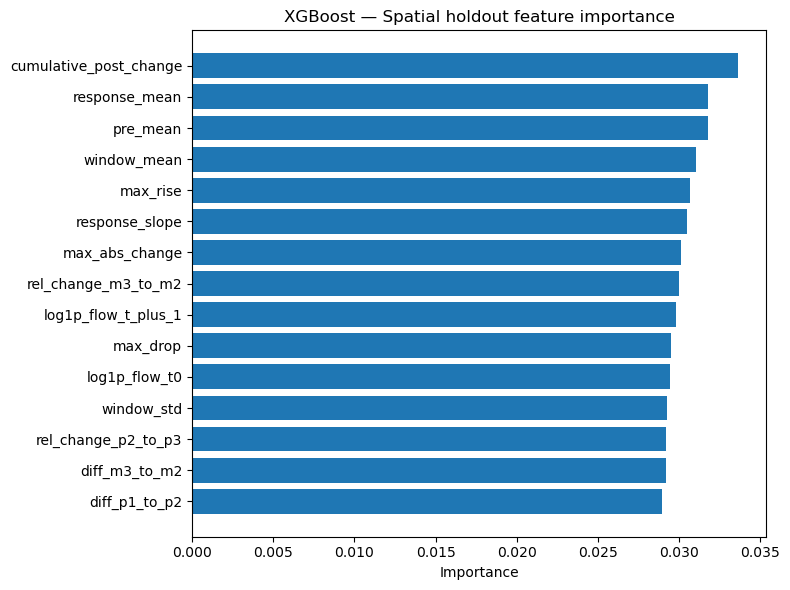

In [9]:

spatial_results = run_xgboost_experiment(
    split_name="Spatial holdout",
    manifest=spatial_manifest,
)


## 7. Final comparison

In [10]:

comparison = pd.concat(
    [grouped_results["metrics"], spatial_results["metrics"]],
    ignore_index=True,
)

comparison.to_csv(
    OUTPUT_DIR / "xgboost_all_metrics.csv",
    index=False,
)

test_comparison = comparison[
    comparison["partition"].eq("test")
].reset_index(drop=True)

print("XGBoost test-set comparison:")
display(test_comparison)

print("\nReference baselines:")
print("Decision Tree grouped/spatial Macro-F1: 0.303 / 0.253")
print("Random Forest grouped/spatial Macro-F1: 0.352 / 0.313")

print("\nSaved files:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print("-", p.name)


XGBoost test-set comparison:


,split_scheme,partition,best_iteration,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,test,615,0.494975,0.352464,0.336239,0.507017
1,Spatial holdout,test,793,0.411376,0.329238,0.286707,0.425028



Reference baselines:
Decision Tree grouped/spatial Macro-F1: 0.303 / 0.253
Random Forest grouped/spatial Macro-F1: 0.352 / 0.313

Saved files:
- grouped_random_best_params.json
- grouped_random_confusion_matrix.png
- grouped_random_early_stopping_curve.png
- grouped_random_feature_importance.csv
- grouped_random_feature_importance.png
- grouped_random_hyperparameter_search.csv
- grouped_random_metrics.csv
- grouped_random_predictions.csv
- grouped_random_test_classification_report.csv
- grouped_random_training_history.csv
- grouped_random_xgboost_model.joblib
- grouped_random_xgboost_model.json
- spatial_holdout_best_params.json
- spatial_holdout_confusion_matrix.png
- spatial_holdout_early_stopping_curve.png
- spatial_holdout_feature_importance.csv
- spatial_holdout_feature_importance.png
- spatial_holdout_hyperparameter_search.csv
- spatial_holdout_metrics.csv
- spatial_holdout_predictions.csv
- spatial_holdout_test_classification_report.csv
- spatial_holdout_training_history.csv
- 


## Interpretation guidance

Focus on:

- test Macro-F1;
- `ACCIDENT` recall and F1;
- the grouped-random versus spatial performance gap;
- the best boosting iteration selected by early stopping;
- whether validation log-loss stops improving long before 2,000 trees;
- whether XGBoost exceeds the Random Forest thresholds:
  - grouped-random Macro-F1: **0.352**
  - spatial holdout Macro-F1: **0.313**

The validation set is used for early stopping and model selection.  
The test set is never used to choose the number of boosting rounds or hyperparameters.
